In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd

from load import load_histograms
from stats import summary, coverage_by_threshold
from plot import plot_distribution, plot_coverage

## Load Histograms
Point this to the directory containing the `trie_X_YYY.csv` files produced by `stats-hcltj`.

In [3]:
data_dir = Path("../../data/children_histogram_wikidata")
histograms = load_histograms(data_dir)
print(f"Loaded {len(histograms)} tries: {', '.join(histograms.keys())}")

Loaded 6 tries: SPO, SOP, POS, PSO, OSP, OPS


## Summary Stats

In [4]:
for name, hist in histograms.items():
    s = summary(hist)
    print(f"{name}: {s['total_nodes']:,} nodes, {s['total_children']:,} children, max={s['max_children']:,}")

SPO: 689,147,007 nodes, 1,456,222,338 children, max=106,829,756
SOP: 106,829,756 nodes, 750,278,285 children, max=6,687
POS: 239,580,168 nodes, 1,006,655,499 children, max=43,109,644
PSO: 5,387 nodes, 582,317,250 children, max=84,677,113
OSP: 952,163,245 nodes, 1,719,238,576 children, max=201,884,959
OPS: 201,884,959 nodes, 239,574,780 children, max=314


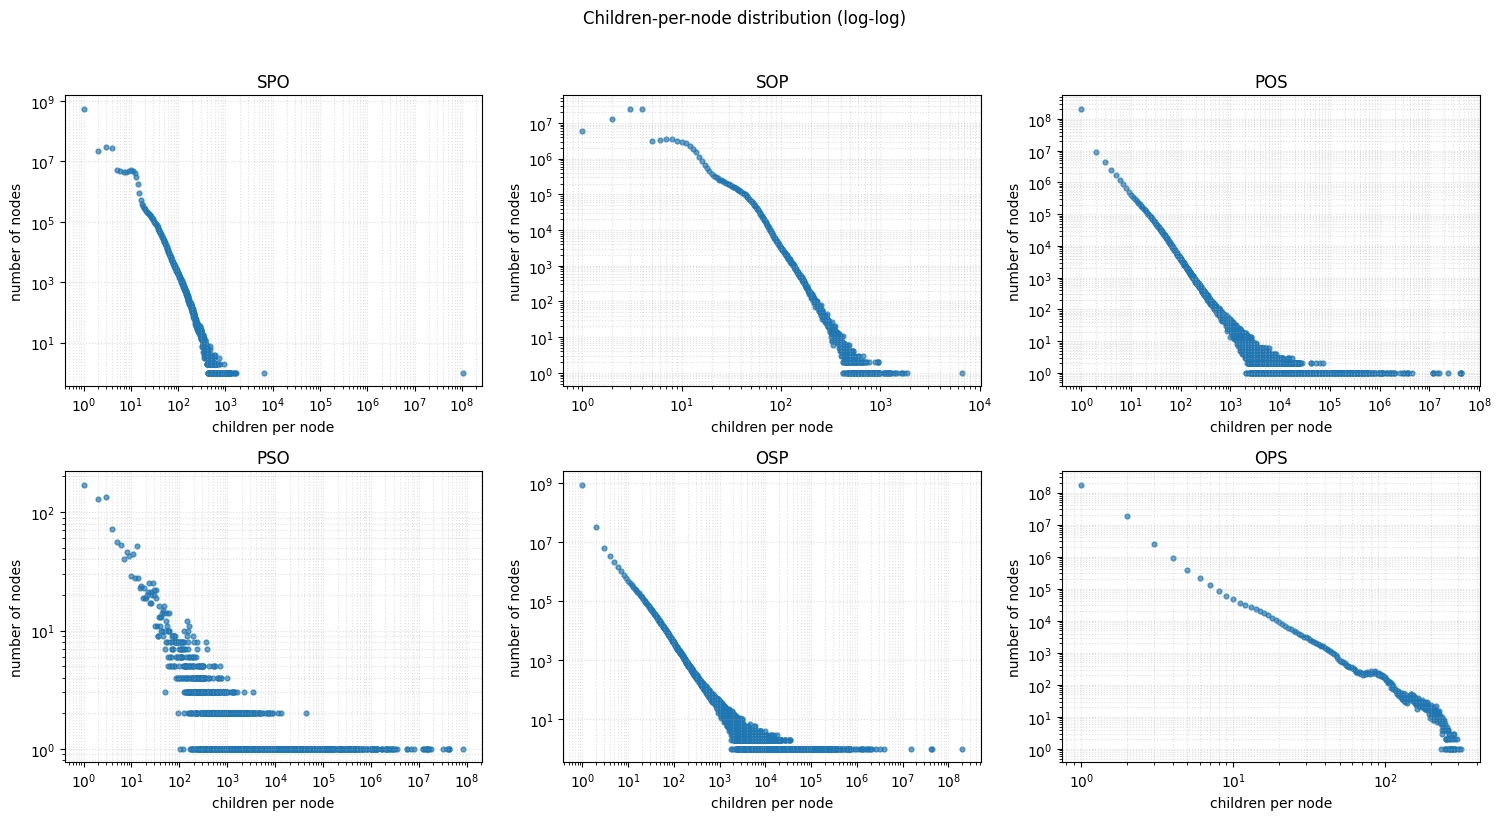

In [5]:
plot_distribution(histograms);

## Threshold Coverage
If we hash nodes with `n_children >= threshold`, what percentage of the total children in the trie are covered by the O(1) hash path?

In [6]:
thresholds = [10, 50, 100, 500, 1000, 4000, 10000]
coverage_tables = {}

for name, hist in histograms.items():
    cov = coverage_by_threshold(hist, thresholds)
    coverage_tables[name] = cov
    print(f"\n--- {name} ---")
    print(cov.to_string())


--- SPO ---
           hashed_nodes  total_nodes     pct_nodes  hashed_children  total_children  pct_children
threshold                                                                                        
10             24554384    689147007  3.563011e+00        482720468      1456222338     33.148816
50               439148    689147007  6.372341e-02        140238486      1456222338      9.630294
100               65779    689147007  9.544988e-03        116211212      1456222338      7.980321
500                 233    689147007  3.380991e-05        106999118      1456222338      7.347718
1000                 23    689147007  3.337459e-06        106862533      1456222338      7.338339
4000                  2    689147007  2.902138e-07        106836411      1456222338      7.336545
10000                 1    689147007  1.451069e-07        106829756      1456222338      7.336088

--- SOP ---
           hashed_nodes  total_nodes     pct_nodes  hashed_children  total_children  pct_chi

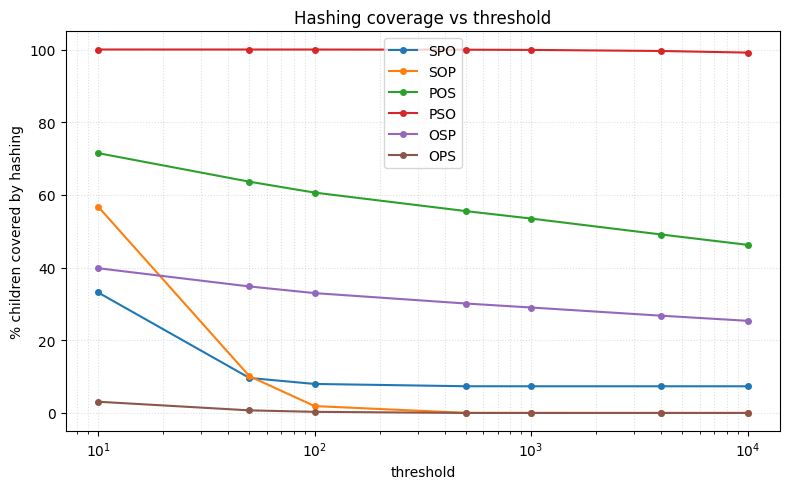

In [7]:
plot_coverage(coverage_tables);